In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

### 1. 머신러닝

#### 문제1. 신생아 건강 데이터 분석 (Newborn_Health.csv)
##### 데이터셋은 신생아(체중 1800g 이하, Low Birth Weight) 관련 정보를 포함하며, 연속형 변수 6~7개와 범주형(Yes/No) 변수 8~10개로 구성됩니다.

- 변수 예시:
- 연속형: 출생체중(g), 임신기간(주), 모체연령, 병원입원일수 등
- 범주형: 쌍둥이여부(Yes/No), 제왕절개여부(Yes/No), 신생아호흡곤란증후군(RDS, Yes/No), 생존여부(0: 사망, 1: 생존) 등
- 뇌손상 관련 변수: D, E, F (각각 None, Mild, Severe, NA)
- 종속변수: 생존여부 (survival, 0/1)


각 컬럼에 대한 설명:

Maternal Age (엄마 나이): 출산 당시 엄마의 나이를 의미합니다.

Gestational Age (임신 주수): 임신 기간을 주 단위로 나타냅니다. 예를 들어, 40주는 만삭을 의미합니다. (마지막 월경 첫날부터 현재까지의 기간을 주단위로 계산하여 태아의 성장과 발달단계를 파악하는 중요한 의학적 지표이다.)

Birth Weight (출생 시 체중): 신생아의 출생 당시 체중을 그램(g) 또는 킬로그램(kg) 단위로 나타냅니다.

APGAR Score 1min (아프가 점수 1분): 출생 후 1분에 측정한 아프가 점수입니다. 아프가 점수는 신생아의 건강 상태를 평가하는 지표로, 피부색, 심박수, 반사 반응, 근긴장도, 호흡 등 5가지 항목을 평가하여 총 0점에서 10점까지 매깁니다.

APGAR Score 5min (아프가 점수 5분): 출생 후 5분에 측정한 아프가 점수입니다. 일반적으로 1분 점수보다 5분 점수가 신생아의 장기적인 예후와 더 관련이 깊다고 알려져 있습니다.

Sex (성별): 신생아의 성별을 나타냅니다 (예: 남, 여 또는 M, F).

Presence of Congenital Abnormality (선천성 기형 유무): 신생아에게 선천성 기형이 있는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Mode of Delivery (분만 방식): 분만 방식을 나타냅니다 (예: 자연 분만, 제왕절개 등).

NICU Admission (신생아 중환자실 입원 여부): 신생아가 출생 후 신생아 중환자실(NICU)에 입원했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

Respiratory Distress Syndrome (RDS) (호흡곤란 증후군 (RDS) 발생 여부): 신생아에게 호흡곤란 증후군이 발생했는지 여부를 나타냅니다 (예: 예/아니오 또는 True/False).

#### 데이터 특이사항:

- 결측값 비율: 약 10~15%
- BrainDamage 변수의 NA 비율: 약 20%
- Python/R로 분석 가능, sklearn/xgboost 패키지 사용 권장.

In [162]:
df = pd.read_csv('Newborn_Health.csv')
df.head()

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,oxygen_days,body_temp,twins,c_section,rds,d,e,f,infection,ventilation,gender,survival
0,1,1599.342831,34.798711,26.624109,9,7,1,36.134429,No,No,No,Severe,None,None,No,No,M,1
1,2,1472.347140,33.849267,29.277407,5,5,1,37.525633,No,Yes,Yes,Severe,NaN,Mild,No,No,F,0
2,3,1629.537708,32.119261,26.037900,12,8,2,37.248637,No,No,Yes,None,None,None,No,Yes,M,1
3,4,1800.000000,30.706126,28.460192,7,7,1,36.714612,No,Yes,No,None,None,Severe,No,No,F,1
4,5,1453.169325,33.396447,20.531927,7,6,4,36.208373,No,Yes,No,NaN,Severe,None,No,No,F,0


#### 1. 교차표 생성:
- 뇌손상 변수 D, E, F를 두 개씩 조합하여 교차표를 작성하고, 각 조합의 데이터 분포를 추정하시오. (예: D와 E의 교차표, E와 F의 교차표 등)

In [163]:
itter = [('d', 'e'), ['d', 'f'], ('e', 'f')]
orders = ['None', 'Mild', 'Severe', 'All']

for i1, i2 in itter:
#     cr = pd.crosstab(df[i1], df[i2], margins=True)
#     cr = cr.reindex(index=orders, columns=orders)
    cr2 = pd.crosstab(df[i1], df[i2], margins=True, normalize=True)
    cr2 = cr2.reindex(index=orders, columns=orders)
#     display(cr)
    display(cr2)

e,None,Mild,Severe,All
d,,,,
None,0.387821,0.150641,0.076923,0.615385
Mild,0.163462,0.052885,0.033654,0.250000
Severe,0.078526,0.040064,0.016026,0.134615
All,0.629808,0.243590,0.126603,1.000000


f,None,Mild,Severe,All
d,,,,
None,0.340157,0.193701,0.077165,0.611024
Mild,0.140157,0.067717,0.037795,0.245669
Severe,0.081890,0.048819,0.012598,0.143307
All,0.562205,0.310236,0.127559,1.000000


f,None,Mild,Severe,All
e,,,,
None,0.367347,0.178964,0.086342,0.632653
Mild,0.139717,0.075353,0.025118,0.240188
Severe,0.067504,0.039246,0.020408,0.127159
All,0.574568,0.293564,0.131868,1.000000


- d-e: d는 양의 왜도를 띄며(None에 약 61% 비중), 무증상->중증으로 갈수록 빈도가 줄어듬
  e 또한 양의 왜도를 띄며, d의 분포와 비슷함, 두 파리미터 모두 무증상인 경우가 약 39%로 가장 높으며, 둘다 중증인 경우가 1.6%로 가장 낮음
- d-f: d, f 모두 양의 왜도를 띄며, 둘다 무증상인 경우가 34%로 가장 높으며, 둘다 중증인 경우 1.26%로 가장 낮음
- f-e: f, e 모두 양의 왜도를 띄며, 둘다 무증상인 경우가 36%로 가장 높으며, 둘다 중증인 경우 2.04%로 가장 낮음

#### 2. 파생변수 생성:
- BrainDamage: D, E, F가 모두 NA이면 0, 하나라도 None/Mild/Severe이면 1, 그 외는 NA로 처리.
- SplitInd: BrainDamage가 0이면 0, NA이면 1, 그 외(1)는 2로 처리.

In [164]:
cols = ['d', 'e', 'f']

cond1 = df[cols].isna().all(axis=1)
cond2 = df[cols].isin(['None', 'Mild', 'Severe']).any(axis=1)

df['brain_dm'] = np.where(cond1, 0, np.where(cond2, 1, np.nan)).astype('O')

df.head()

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,oxygen_days,body_temp,twins,c_section,rds,d,e,f,infection,ventilation,gender,survival,brain_dm
0,1,1599.342831,34.798711,26.624109,9,7,1,36.134429,No,No,No,Severe,None,None,No,No,M,1,1
1,2,1472.347140,33.849267,29.277407,5,5,1,37.525633,No,Yes,Yes,Severe,NaN,Mild,No,No,F,0,1
2,3,1629.537708,32.119261,26.037900,12,8,2,37.248637,No,No,Yes,None,None,None,No,Yes,M,1,1
3,4,1800.000000,30.706126,28.460192,7,7,1,36.714612,No,Yes,No,None,None,Severe,No,No,F,1,1
4,5,1453.169325,33.396447,20.531927,7,6,4,36.208373,No,Yes,No,NaN,Severe,None,No,No,F,0,1


In [165]:
# SplitInd: BrainDamage가 0이면 0, NA이면 1, 그 외(1)는 2로 처리

df['splitind'] = np.where(df['brain_dm'] == 0, 0, np.where(df['brain_dm'] == np.nan, 1, 2)).astype('O')

df.head()

,id,birth_weight,gestational_age,maternal_age,hospital_days,apgar_score,oxygen_days,body_temp,twins,c_section,rds,d,e,f,infection,ventilation,gender,survival,brain_dm,splitind
0,1,1599.342831,34.798711,26.624109,9,7,1,36.134429,No,No,No,Severe,None,None,No,No,M,1,1,2
1,2,1472.347140,33.849267,29.277407,5,5,1,37.525633,No,Yes,Yes,Severe,NaN,Mild,No,No,F,0,1,2
2,3,1629.537708,32.119261,26.037900,12,8,2,37.248637,No,No,Yes,None,None,None,No,Yes,M,1,1,2
3,4,1800.000000,30.706126,28.460192,7,7,1,36.714612,No,Yes,No,None,None,Severe,No,No,F,1,1,2
4,5,1453.169325,33.396447,20.531927,7,6,4,36.208373,No,Yes,No,NaN,Severe,None,No,No,F,0,1,2


#### 3. 데이터 전처리:
- 결측값 처리: 연속형 변수는 중앙값으로, 범주형 변수는 최빈값으로 대체.
- 불필요한 변수(예: ID, 상수값 변수) 제거.

In [166]:
# d, e, f 모두 범주형 변수이므로 최빈값으로 치환
for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    
#불필요 변수 제거
df.drop(columns='id', inplace=True)
print(df.isna().sum())

birth_weight       0
gestational_age    0
maternal_age       0
hospital_days      0
apgar_score        0
oxygen_days        0
body_temp          0
twins              0
c_section          0
rds                0
d                  0
e                  0
f                  0
infection          0
ventilation        0
gender             0
survival           0
brain_dm           0
splitind           0
dtype: int64


모든 결측치가 제거되었다.(명목형 변수 최빈값으로 대체)

#### 4. EDA (탐색적 데이터 분석):
- 생존여부(survival)와 BrainDamage에 따른 주요 변수(출생체중, 임신기간 등)의 분포를 시각화하고 상관관계 분석.

In [170]:
df['survival'] = df['survival'].astype('O')

In [174]:
c_cols = df.select_dtypes('O').columns.tolist()[:-3]+ ['splitind']
n_cols = df.select_dtypes('number').columns.tolist()
obj = ['survival', 'brain_dm']


print("<<명목형 변수 통계량>>")
display(df[c_cols].describe().T)
print("<<연속형 변수 통계량>>")
display(df[n_cols].describe().T)

<<명목형 변수 통계량>>


,count,unique,top,freq
twins,1000,2,No,904
c_section,1000,2,No,587
rds,1000,2,No,675
d,1000,3,None,699
e,1000,3,None,707
f,1000,3,None,654
infection,1000,2,No,803
ventilation,1000,2,No,720
gender,1000,2,F,501
splitind,1000,2,2,994


<<연속형 변수 통계량>>


,count,mean,std,min,25%,50%,75%,max
birth_weight,1000.0,1497.507539,183.028100,851.746532,1370.481939,1505.060122,1629.588775,1800.000000
gestational_age,1000.0,32.141142,1.907676,28.000000,30.787517,32.126154,33.457764,36.000000
maternal_age,1000.0,30.035634,4.867969,18.000000,26.760002,29.998746,33.304577,45.000000
hospital_days,1000.0,9.975000,3.067864,5.000000,8.000000,10.000000,12.000000,21.000000
apgar_score,1000.0,6.416000,1.735499,4.000000,5.000000,6.000000,8.000000,9.000000
oxygen_days,1000.0,1.929000,1.337815,0.000000,1.000000,2.000000,3.000000,7.000000
body_temp,1000.0,36.806771,0.305139,36.000000,36.605420,36.808658,37.006225,37.813215


- 명목형 변수: 쌍둥이 아님, c_section, rds, ventilation NO 비율이 압도적으로 많음
  d, e, f None값이 압도적으로 많음, 성별은 균형적ㅇ이며, 뇌손상, splitind 있는 비율이 99% 이상임

목적변수 : survival


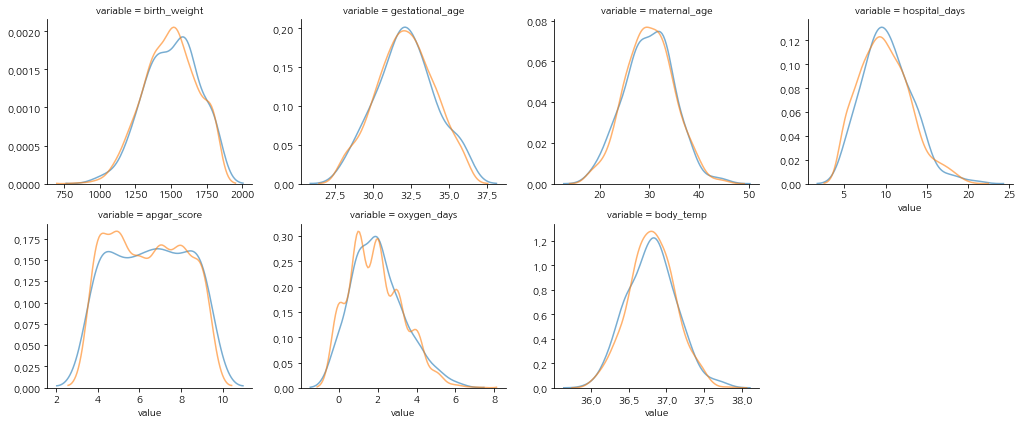

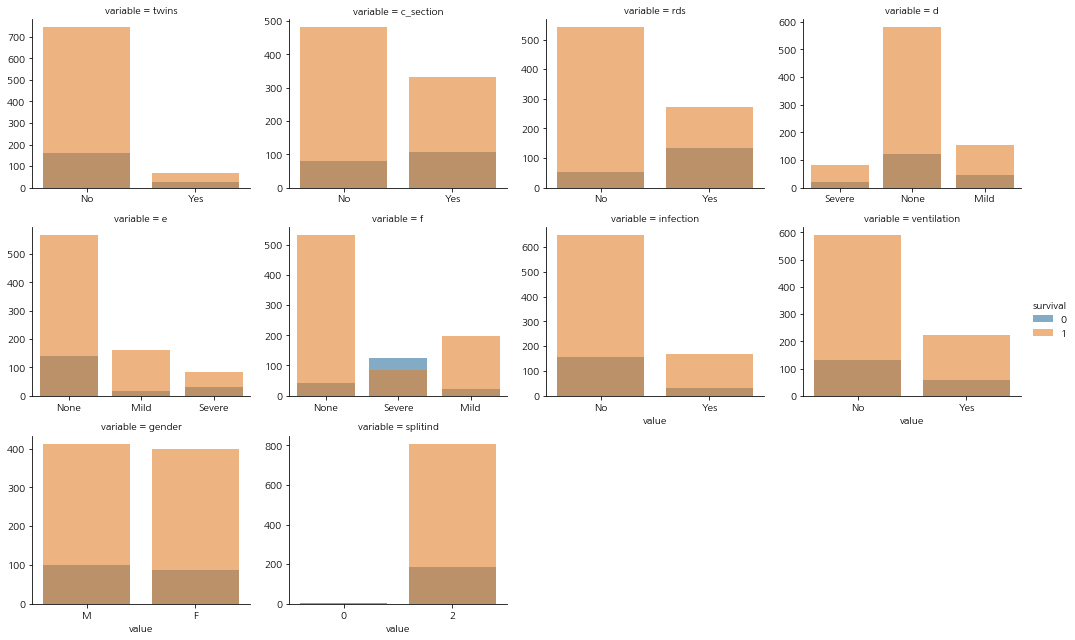

목적변수 : brain_dm


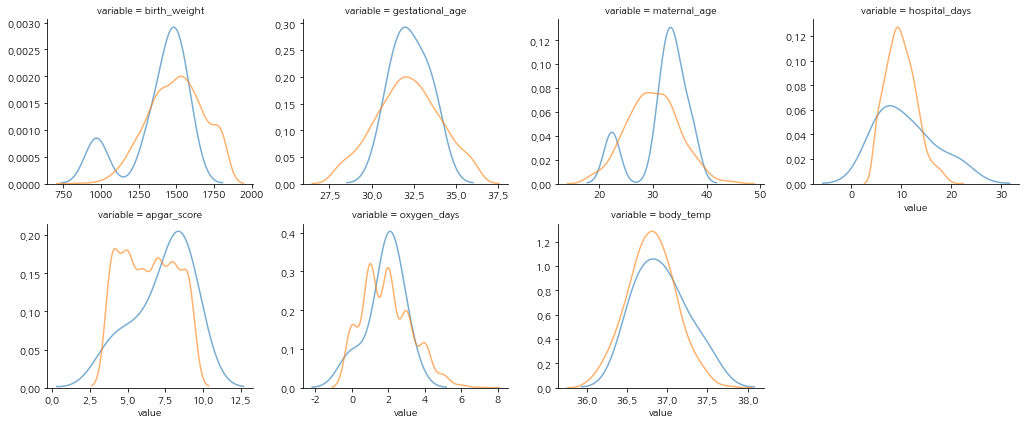

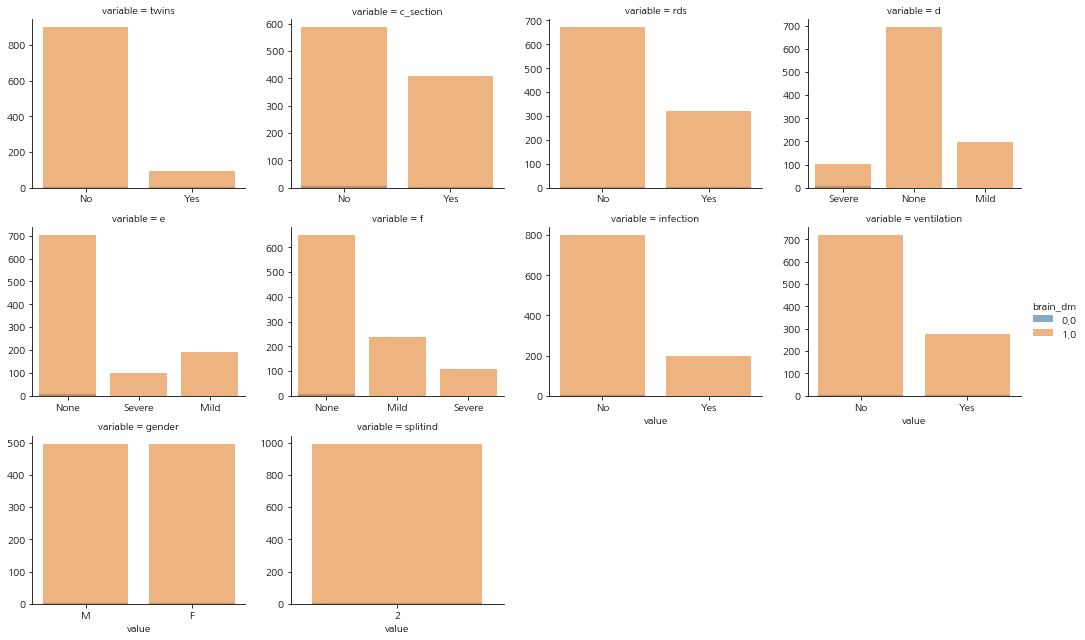

In [180]:
for ob in obj:
    print(f"목적변수 : {ob}")
    mt = df.melt(id_vars=ob, value_vars=n_cols)
    g = sns.FacetGrid(mt, col='variable', hue=ob, col_wrap=4, height=3, aspect=1.2, sharex=False, sharey=False)
    g.map(sns.kdeplot, 'value', alpha=0.6)
    plt.show()
    m2 = df.melt(id_vars=ob, value_vars=c_cols)
    g = sns.FacetGrid(m2, col='variable', hue=ob, col_wrap=4, height=3, aspect=1.2, sharex=False, sharey=False)
    g.map(sns.countplot, 'value', alpha=0.6)
    g.add_legend()
    plt.show()

1. 목적변수 : survival
- 연속형 변수의 경우 두 레이블(생존, 사망) 의 분포가 유사함
- 명목형 변수의 경우 생존의 경우가 사망한 경우보다 확인히 크며, 사망한 영아의 경우 rds가 있는 비율이 높았음  
   e, f(특히) 뇌손상 계수의 중태 비율이 생존영아보다 높았음  
2. 뇌손상 여부
- 연속형 변수의 경우 분포 모양의 차이가 확연히 있음, 출생몸무게와 산모나이는 뇌손상 여부가 없을 때 쌍봉분포를 보이며 범위가 비교적  
  작으나, 뇌손상이 있는 경우는 범위가 넓음, 뇌손상 있는 경우 체온이 높은 경향이 있으며, 아프가 점수의 경우에도 균등분포를 보이며  
  비교적 높은 편

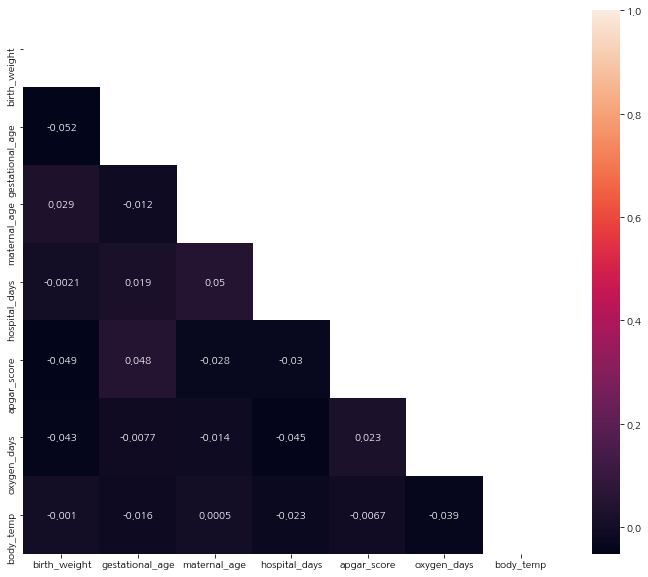

In [182]:
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)

plt.show()

각 수치형 변수들 간 유의미한 선형 상관관계는 관찰되지 않는다. 

#### 분류 분석:
- 단일 분류: 로지스틱 회귀 또는 의사결정나무를 사용하여 survival 예측.
- 앙상블 분류: 랜덤포레스트와 XGBoost를 사용하여 survival 예측.
- 모델 성능 비교(Accuracy, F1-Score, ROC-AUC).

불균형 데이터이므로 오버샘플링 고려

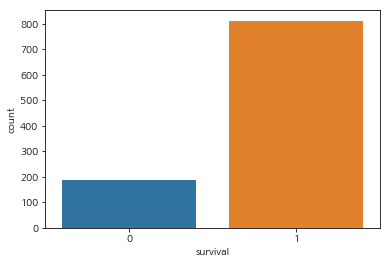

In [183]:
sns.countplot(df['survival'])
plt.show()

In [186]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 데이터 분할
x = df.drop('survival', axis=1)
y = df['survival'].astype('int')

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42, stratify=y)

c_cols = train_x.select_dtypes('O').columns
n_cols = train_x.select_dtypes('number').columns

processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder = 'passthrough'
)

#단일모델
lr = Pipeline([
    ('preprocessing', processor), 
    ('cl', LogisticRegressionCV(random_state=42))
])

dt = Pipeline([
    ('preprocessing', processor), 
    ('cl', DecisionTreeClassifier(random_state=42))
])

#앙상블
rf = Pipeline([
    ('preprocessing', processor), 
    ('cl', RandomForestClassifier(random_state=42))
])

xgb = Pipeline([
    ('preprocessing', processor), 
    ('cl', XGBClassifier(random_state=42))
])

model_list = [('단일', '로지스틱', lr), ('단일', '의사결정', dt), ('앙상블', '랜덤포레스트', rf), ('앙상블', 'xgb', xgb)]
dt_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['구분', '모델명', '데이터', 'acc', 'f1', 'roc_auc'])
for o, m_name, model in model_list:
    model.fit(train_x, train_y)
    for dname, x, y in dt_list:
        pred = model.predict(x)
        acc = accuracy_score(y, pred)
        f1 = f1_score(y, pred)
        auc = roc_auc_score(y, pred)
        rs.loc[len(rs)] = [o, m_name, dname, acc, f1, auc]
display(rs)

,구분,모델명,데이터,acc,f1,roc_auc
0,단일,로지스틱,train,0.813333,0.897059,0.500000
1,단일,로지스틱,test,0.812000,0.896247,0.500000
2,단일,의사결정,train,1.000000,1.000000,1.000000
3,단일,의사결정,test,0.700000,0.818402,0.480086
4,앙상블,랜덤포레스트,train,1.000000,1.000000,1.000000
5,앙상블,랜덤포레스트,test,0.812000,0.896247,0.500000
6,앙상블,xgb,train,0.838667,0.909769,0.567857
7,앙상블,xgb,test,0.816000,0.898230,0.510638


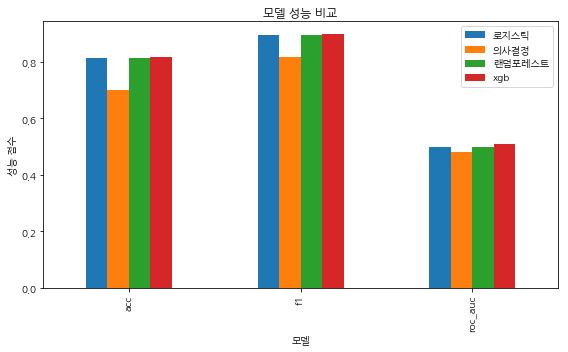

In [191]:
# 모델학습 후 성능비교 시각화
tmp = rs[rs['데이터'] == 'test'].drop(columns=['데이터', '구분']).T
tmp.columns = tmp.iloc[0].values
tmp = tmp[1:]
ax = tmp.plot(kind='bar', figsize=(8, 5))

# 축 레이블 및 제목 설정
ax.set_xlabel('모델')
ax.set_ylabel('성능 점수')
ax.set_title('모델 성능 비교')

plt.tight_layout()
plt.show()

단일모델과 앙상블 모델로 모델학습을 수행했다. f1, accuracy, roc_auc 점수로 성능을 판단할 때, 
단일모델은 로지스틱 모델이 비교적 높은 성능을 보여주었으며, 앙상블 모델은 xgb 모델의 결과가 모든 지표에 대해서 성능이 뛰어났다.  
xgb의 성능이 가장 좋았으며, 과적합도 없었다.  
(의사결정, 랜덤포레스트 모델의 경우 train/test set 성능차이[과적합]를 보였다.)  

Roc_Auc 점수를 볼 때 0.510638로 동전 던지기 수준의 무작위 확률 점수가 나왔는데, 이는 심한 데이터 불균형으로 인해  
SMOTE로 보간을 했어도 minority class를 오분류(recall 낮음, 사망을 생존으로 오분류)한 것임을 알 수 있다.  
더 효과적인 파생변수를 생성하거나 관찰데이터를 증강하는 등의 작업이 필요하다. 

### 2. 머신러닝

#### [문제 2] 재생에너지 발전량 예측 (Energy.csv, Climate.csv)
#### 두 데이터셋은 2021~2023년 3년간의 재생에너지 발전량과 기후 데이터를 포함합니다.

- Energy.csv:
- 변수: date(YYYYMMDD), source(태양광/풍력), generation(MWh), hour_0~hour_23(시간별 발전량)
총 발전량(generation)은 태양광과 풍력의 합.
- Climate.csv:
- 변수: date(YYYY-MM-DD), temperature(기온), humidity(습도), windspeed(풍속), precipitation(강수량)
- 일부 변수(temperature, precipitation)에 결측값 존재.

#### 데이터 특이사항:

- Energy.csv: 약 1000일 데이터, 결측값 5% 이하.
- Climate.csv: 약 1100일 데이터, 결측값 10% 내외.
- Python(Pandas, sklearn) 또는 R(dplyr, caret)로 분석 가능.

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

d2 = pd.read_csv('Energy.csv')
d3 = pd.read_csv('Climate.csv')
d2.drop(columns=['generation'], inplace=True, axis=1)
display(d2.head())
display(d3.head())

,date,source,hour_0,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,20210101,Solar,10.612776,18.919571,16.477538,8.827337,11.027004,7.320036,10.068342,4.565273,...,13.887643,11.554141,6.316949,1.052565,11.417600,15.073001,10.228990,13.390003,2.489640,9.963013
1,20210101,Wind,7.421830,5.520150,13.688934,19.836831,13.963826,9.462576,4.057822,16.606856,...,7.451766,8.677991,10.594264,13.060985,13.648189,4.026717,7.523877,19.683184,10.749592,0.637982
2,20210102,Solar,16.843117,7.082532,17.834894,5.903762,7.068822,7.476683,1.746394,4.873352,...,12.921522,11.551500,21.283893,6.781420,12.665406,12.035176,11.307375,17.278912,6.939721,2.568380
3,20210102,Wind,6.527484,4.081912,25.683430,15.869641,10.594932,23.009171,5.265074,3.742647,...,12.606121,6.423788,17.117713,7.361706,1.396033,12.943102,8.819983,10.153434,14.098082,14.236364
4,20210103,Solar,11.144246,13.060810,17.157265,17.923698,9.272692,12.561377,12.055105,9.167380,...,9.896769,8.531589,12.683250,11.809802,9.818225,2.075185,17.261561,12.466698,16.477671,15.787612


,date,temperature,humidity,windspeed,precipitation
0,2021-01-01,8.196357,60.767346,7.229558,0.133543
1,2021-01-02,7.842254,71.605808,1.878436,3.203037
2,2021-01-03,8.548918,46.904014,4.651294,2.122495
3,2021-01-04,25.446324,87.003296,0.126070,2.307601
4,2021-01-05,14.434452,52.582675,3.209874,0.562203


#### 2. 결측값 처리:
- temperature, precipitation은 결측값을 0으로 대체.
- 그 외 변수(humidity, windspeed 등)는 직전 값(Forward Fill)으로 대체.

In [245]:
# 일단 날짜형 변환
d2['date'] = pd.to_datetime(d2['date'], format='%Y%m%d')
d3['date'] = pd.to_datetime(d3['date'], format='%Y-%m-%d')


#결측값 처리
d3[['temperature', 'precipitation']] = d3[['temperature', 'precipitation']].fillna(0)
d3[['humidity', 'windspeed']] = d3[['humidity', 'windspeed']].fillna(method='ffill')

d3.isna().sum()

date             0
temperature      0
humidity         0
windspeed        0
precipitation    0
dtype: int64

In [246]:
d2 = d2.fillna(method='ffill')

d2.isna().sum()

date       0
source     0
hour_0     0
hour_1     0
hour_2     0
hour_3     0
hour_4     0
hour_5     0
hour_6     0
hour_7     0
hour_8     0
hour_9     0
hour_10    0
hour_11    0
hour_12    0
hour_13    0
hour_14    0
hour_15    0
hour_16    0
hour_17    0
hour_18    0
hour_19    0
hour_20    0
hour_21    0
hour_22    0
hour_23    0
dtype: int64

In [247]:
mt = d2.melt(id_vars=['date', 'source'], var_name='time', value_name='generation')

mt['time'] = mt['time'].str.replace('hour_', '').astype('int').round(0)

In [248]:
display(mt.head())
display(d3.head())

print(mt.shape, d3.shape)

,date,source,time,generation
0,2021-01-01,Solar,0,10.612776
1,2021-01-01,Wind,0,7.421830
2,2021-01-02,Solar,0,16.843117
3,2021-01-02,Wind,0,6.527484
4,2021-01-03,Solar,0,11.144246


,date,temperature,humidity,windspeed,precipitation
0,2021-01-01,8.196357,60.767346,7.229558,0.133543
1,2021-01-02,7.842254,71.605808,1.878436,3.203037
2,2021-01-03,8.548918,46.904014,4.651294,2.122495
3,2021-01-04,25.446324,87.003296,0.126070,2.307601
4,2021-01-05,14.434452,52.582675,3.209874,0.562203


(52560, 4) (1095, 5)


In [249]:
mg = pd.merge(mt, d3, how='left', on='date', sort=True)
display(mg)
mg.shape

,date,source,time,generation,temperature,humidity,windspeed,precipitation
0,2021-01-01,Solar,0,10.612776,8.196357,60.767346,7.229558,0.133543
1,2021-01-01,Wind,0,7.421830,8.196357,60.767346,7.229558,0.133543
2,2021-01-01,Solar,1,18.919571,8.196357,60.767346,7.229558,0.133543
3,2021-01-01,Wind,1,5.520150,8.196357,60.767346,7.229558,0.133543
4,2021-01-01,Solar,2,16.477538,8.196357,60.767346,7.229558,0.133543
...,...,...,...,...,...,...,...,...
52555,2023-12-31,Wind,21,13.667285,1.380298,84.825030,1.722135,2.536025
52556,2023-12-31,Solar,22,8.392613,1.380298,84.825030,1.722135,2.536025
52557,2023-12-31,Wind,22,13.123596,1.380298,84.825030,1.722135,2.536025
52558,2023-12-31,Solar,23,4.255613,1.380298,84.825030,1.722135,2.536025


(52560, 8)

#### 3. 파생변수 생성:
- Season: 월을 기준으로 계절 변수 생성 (3-5월: 봄, 6-8월: 여름, 9-11월: 가을, 12-2월: 겨울).

봄     13248
여름    13248
가을    13104
겨울    12960
Name: season, dtype: int64


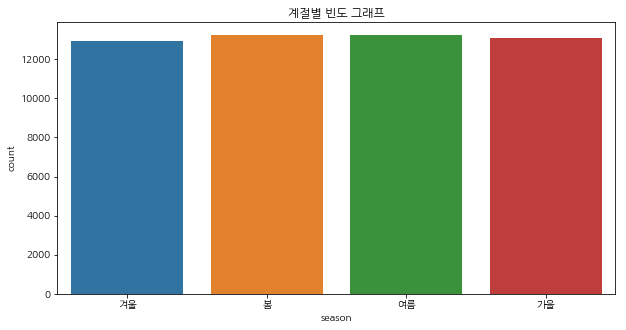

In [250]:
#계절변수 생성
mg['month'] = mg['date'].dt.month

cond1 = mg['month'].between(3, 5)
cond2 = mg['month'].between(6, 8)
cond3 = mg['month'].between(9, 11)

mg['season'] = np.where(cond1, '봄', 
                        np.where(cond2, '여름', 
                                np.where(cond3, '가을', '겨울')))

print(mg['season'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(mg['season'])
plt.title('계절별 빈도 그래프')
plt.show()

계절별 비율분포가 유사한 것을 알 수 있다.

#### 4. 탐색적 분석:
- 변수 간 상관관계 분석(예: generation과 temperature, windspeed 간 상관계수).
- 계절별 발전량 분포 시각화.

In [284]:
from scipy.stats import shapiro, mannwhitneyu, kruskal

cs = ['source', 'season']

for col in cs:
    gr = [(name, g['generation']) for name, g in mg.groupby(col)]
    print("- 정규성 검정결과")
    for name, g in gr:
        stat, p = shapiro(g)
        print(f"  - {col} - {name}: pvalue: {p:.3f}")
    if len(gr) > 2:
        print("- 크루스칼왈리스 검정")
        stat, p = kruskal(gr[0][1], gr[1][1], gr[2][1], gr[3][1])
    else: 
        print("- 맨휘트니u 검정")
        stat, p = mannwhitneyu(gr[0][1], gr[1][1])
    print(f"  - {col} pvalue: {p:.3f}")

- 정규성 검정결과
  - source - Solar: pvalue: 0.000
  - source - Wind: pvalue: 0.000
- 맨휘트니u 검정
  - source pvalue: 0.277
- 정규성 검정결과
  - season - 가을: pvalue: 0.000
  - season - 겨울: pvalue: 0.000
  - season - 봄: pvalue: 0.000
  - season - 여름: pvalue: 0.000
- 크루스칼왈리스 검정
  - season pvalue: 0.552


In [296]:
# 두 변수의 누적확률분포 비교를 통한 분포 차이 검정: 분포 동일(즉, 특징차이 통계적으로 없음)
from scipy.stats import ks_2samp
nn = ['time', 'temperature', 'humidity', 'windspeed', 'precipitation']

for col in nn:
    stat, p = ks_2samp(mg['generation'], mg[col])
    print(f"- {col} ks 검정결과: {p:.3f}")

- time ks 검정결과: 0.000
- temperature ks 검정결과: 0.000
- humidity ks 검정결과: 0.000
- windspeed ks 검정결과: 0.000
- precipitation ks 검정결과: 0.000


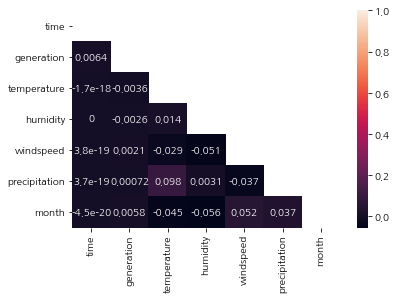

In [252]:
corr = mg.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

수치형 변수 간 상관관계 분석을 수행한다.  
보편적으로 많이 사용하는 피어슨 선형 상관관계 분석을 실시한다. 

변수간의 1:1 선형 상관관계 분석 후 유의미한 상관관계가 존재하지 않는 것을 확인했다. 

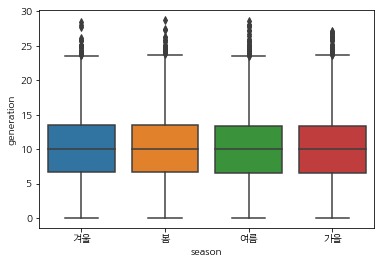

In [288]:
sns.boxplot(data=mg, y='generation', x='season')
plt.show()

겨울>여름>봄>가을 순으로 데이터 수가 많으며,  각 계절별 발전량 분포는 비슷하다. 

#### 5. 데이터 분할 및 예측:
- 2021~2022년 데이터를 학습(train), 2023년 데이터를 테스트(test)로 분할.
- 선형회귀, 랜덤포레스트를 사용하여 총 발전량(generation) 예측.
- 성능 평가: RMSE, R².

In [253]:
train = mg[mg['date'].dt.year.between(2021, 2022)]
test = mg[mg['date'].dt.year == 2023]
train.shape, test.shape

((35040, 10), (17520, 10))

In [297]:
train_x, train_y = train.drop(['generation', 'date', 'month', 'time'], axis=1), train['generation']
test_x, test_y = test.drop(['generation', 'date', 'month','time'], axis=1), test['generation']

In [298]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


c_cols = train_x.select_dtypes('O').columns
n_cols = train_x.select_dtypes('number').columns

processor = make_column_transformer(
    (Pipeline([('scaler', MinMaxScaler())]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder = 'passthrough'
)

processor2 = make_column_transformer(
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder = 'passthrough'
)

#단일모델
lr = Pipeline([
    ('preprocessing', processor), 
    ('cl', LinearRegression())
])


#앙상블
rf = Pipeline([
    ('preprocessing', processor2), 
    ('cl', RandomForestRegressor(random_state=42))
])


model_list = [('단일', '선형회귀', lr), ('앙상블', '랜덤포레스트', rf)]
dt_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['구분', '모델명', '데이터', 'r2', 'rmse'])
for o, m_name, model in model_list:
    model.fit(train_x, train_y)
    for dname, x, y in dt_list:
        pred = model.predict(x)
        
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        
        rs.loc[len(rs)] = [o, m_name, dname, r2, rmse]
display(rs)

,구분,모델명,데이터,r2,rmse
0,단일,선형회귀,train,0.000059,4.897313
1,단일,선형회귀,test,-0.000153,4.918358
2,앙상블,랜덤포레스트,train,0.041078,4.795814
3,앙상블,랜덤포레스트,test,-0.005421,4.931292


In [274]:
4.918658/(test_y.max() - test_y.min())

0.18062673203990084

두 모델을 r2, rmse를 성능지표로 비교했을 때 선형회귀의 성능이 확연히 좋았다.(test: r2[-0.000275], rmse[4.918658])
랜덤포레스트는 과적합이 보이나, 선형회귀는 train/test set 성능이 균일하며, test set 범위 대비 약 18%의 표준오차를 보인다.  
r2 score는 음수로 나타나며, 이는 모델의 예측성능이 단순한 평균값을 사용하는 것보다 나쁘다는 것을 의미한다.  


앞서 종속변수와 설명변수 간 상관관계가 없다는 것을 확인하였으며, 이는 설명변수가 종속변수를 예측하는데 적절한 특징을 가지고 있지  
않다는 것을 의미한다. 따라서 모델예측성능을 높이기 위해 데이터의 품질을 재검토, 적절한 예측특징을 반영한 새로운 파생변수를   
생성하는 것을 고려한다.

#### [문제 3] 분산분석: 학습방법과 성별에 따른 성적 분석
#### 데이터셋은 학생 40명(남 20, 여 20)의 학습방법(3가지)별 성적을 포함합니다.
##### 변수:
- ID: 학생 식별자
- Gender: 성별 (M/F)
- LearningMethod: 학습방법 (Traditional, Online, Blended)
- Score: 성적 (0~100점)
##### 데이터 특이사항:
- 성적 분포: 평균 75, 표준편차 10 내외.
- Python(statsmodels) 또는 R(aov, TukeyHSD) 사용 권장.

In [4]:
d3 = pd.read_csv('./Learning_Score.csv')

d3.head()

,id,Gender,Traditional,Online,Blended
0,1,M,89,65,58
1,2,M,73,82,76
2,3,M,80,82,74
3,4,M,83,50,93
4,5,M,78,56,86


먼저 각 id별로 중복되는 값이 있는지 확인-> 없음  
종속변수는 연속형(성적), 설명변수는 between 성별(명목형 2그룹), within(명목형 3그룹) 이며 독립요인과 반복요인이 혼합된 형태이므로  
혼합 설계 ANOV, 해당 ANOVA의 전제조건은 다음과 같다.   

- 독립성: 독립요인 관찰값은 서로 독립
- 정규성: 각 그룹 내 잔차는 정규분포 따름
- 구형성: 반복측정 요인수준 간 공분산 행렬이 동일
- 등분산성: 독립요인 그룹간 분산 동일

* 이 중 구형성은 모델 학습결과의 Grean house 에타로 확인한다. 1에 가까울수록 구형성 가정을 만족한다고 본다.  
  나머지 가정은 잔차를 통해 검정한다. 

#### 1. 가정 검토:
- 정규성 검정(Shapiro-Wilk 테스트).
- 등분산 검정(Levene 테스트).

In [6]:
mt = d3.melt(id_vars=['id', 'Gender'], var_name='method', value_name='score')

In [10]:
from scipy.stats import shapiro, levene

gr = [(name, g['score']) for name, g in mt.groupby(['Gender', 'method'])]

for name, g in gr:
    stat, p = shapiro(g)
    print(f"{name} 그룹 shapiro 통계량 : {stat:.3f} / p: {p:.3f}", p < 0.05)

('F', 'Blended') 그룹 shapiro 통계량 : 0.948 / p: 0.339 False
('F', 'Online') 그룹 shapiro 통계량 : 0.919 / p: 0.094 False
('F', 'Traditional') 그룹 shapiro 통계량 : 0.956 / p: 0.476 False
('M', 'Blended') 그룹 shapiro 통계량 : 0.961 / p: 0.566 False
('M', 'Online') 그룹 shapiro 통계량 : 0.923 / p: 0.115 False
('M', 'Traditional') 그룹 shapiro 통계량 : 0.977 / p: 0.886 False


모든 그룹에서 정규성을 만족한다. 

In [16]:
# 등분산성 검정
g = [g['score'] for name, g in mt.groupby(['Gender'])]
stat, p = levene(*g)

print(f"levene 등분산성 검정결과 통계량 : {stat:.3f} / pvalue: {p:.3f}")

levene 등분산성 검정결과 통계량 : 0.223 / pvalue: 0.638


독립요인(성별) 그룹 간 등분산성 역시 만족한다.  

#### 2. 분산분석:
- 성별(Gender)과 학습방법(LearningMethod)의 주효과 및 상호작용 효과 분석(mixed  ANOVA)

유의수준 5% 하 가설수립

<주효과>  
1. 독립요인(성별)
  - 귀무가설: 성별에 따른 성적차이가 없다. 
  - 대립가설: 성별에 따른 성적차이가 있다. 
2. 반복요인(학습방법)
  - 귀무가설: 학습방법에 따른 성적차이가 없다.
  - 대립가설: 적어도 한 그룹의 학습방법에 따른 성적차이가 있다.
  
<교호작용>
- 귀무가설: 성별과 학습방법은 서로 독립이다.
- 대립가설: 성별과 학습방법은 서로 연관이 있다.

In [17]:
import pingouin as pg

mix_model = pg.mixed_anova(dv='score', within='method', between='Gender', subject='id', data=mt)
display(mix_model)

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Gender,0.033333,1,38,0.033333,0.000260,9.872168e-01,0.000007,NaN
1,method,4539.216667,2,76,2269.608333,22.577354,2.013656e-08,0.372703,0.995929
2,Interaction,118.816667,2,76,59.408333,0.590976,5.563113e-01,0.015314,NaN


먼저 구형성을 확인하면 반복요인(method)의 GG eps값이 0.995929로 1에 가까우므로 구형성 가정을 만족한다.  

먼저 교호작용은 확인하면 F 통계량 p-value가 0.5563113이므로 0.05보다 크므로 귀무가설을 기각할 수 없다.  
(성별과 학습방법은 서로 독립이다.)  

따라서 주효과 검정에 영향을 주지 않으므로 주효과를 분석한다.  
독립요인인 성별은 0.9872168의 pvalue로 귀무가설을 기각할 수 없음(성별에 따른 성적차이가 없다)   
반복요인인 교육방식은 2.013656e-08로 귀무가설을 기각함  


따라서 반복요인인 교육방식에 대한 것만 유의하므로 해당문제는 일원 반복측정 ANOVA 문제와 동일하다.  
다시 모델 적합을 한다. 

In [21]:
r_model = pg.rm_anova(dv='score', within='method', subject='id', data=mt)
display(r_model)

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,method,2,78,22.816651,1.579088e-08,0.369102,0.995929


마찬가지로 구형성은 만족하며, 통계적으로 유의한 모델이다.   
(적어도 한 그룹의 학습방법에 따른 성적차이가 있다.)  
효과 크기는 0.369로 전체 변동의 약 36.9%를 설명 가능하다.    

어느 그룹에서 통계적으로 유의한지 확인하기 위해 tukey HSD test를 수행한다. 

잔차 shapiro 정규성 검정: 0.234 False


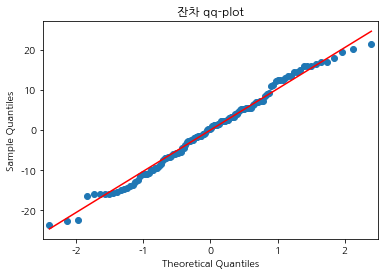

더빈왓슨 검정결과 : 2.101713267055465


In [25]:
# 잔차 기본가정 확인

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

model = smf.ols('score~C(method)', data=mt).fit()

stat, p = shapiro(model.resid)
print(f"잔차 shapiro 정규성 검정: {p:.3f}", p < 0.05)
sm.qqplot(model.resid, line='s')
plt.title('잔차 qq-plot')
plt.show()

dw = durbin_watson(model.resid)

print(f"더빈왓슨 검정결과 : {dw}")

반복측정 ANOVA의 기본가정인 잔차의 정규성, 구형성, 독립성을 만족한다.  

#### 3. 사후분석:
- 유의미한 효과가 발견될 경우, Tukey HSD 테스트로 사후분석 수행.

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
Blended      Online  -14.525    0.0 -20.0399 -9.0101   True
Blended Traditional     -3.8 0.2348  -9.3149  1.7149  False
 Online Traditional   10.725    0.0   5.2101 16.2399   True
-----------------------------------------------------------


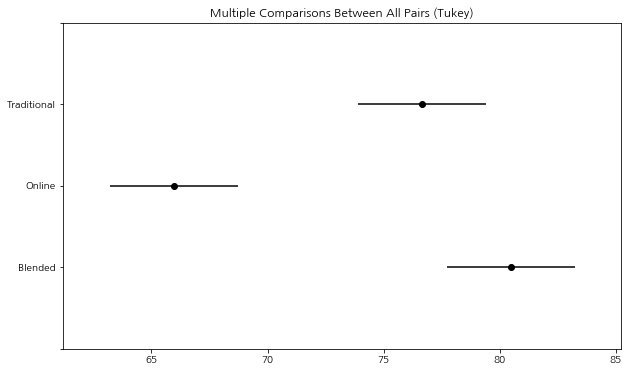

In [27]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=mt['score'], groups=mt['method'], alpha=0.05)

print(rs)

rs.plot_simultaneous()
plt.show()

#### 4. 결과 해석:
- 각 효과의 p-value와 통계적 유의성 논의.
- 학습방법별 평균 성적 비교 시각화.

- Blended -  Online: 통계적으로 유의함(점수 차이가 있음) (pvalue : 0.0)
- Blended - Traditional: 통계적으로 유의하지 않음(점수차이 없음) (0.2348 )
- Online - Traditional: 통계적으로 유의함 (0.0)

온라인 방식에 비해서 전통적, Blended 방식은 점수향상에 유의미한 효과가 있으나, 전통적 - Blended 간에는 통계적으로 유의미한  
차이가 없다.  따라서 온라인교육을 수강하고 있고 점수향상을 원한다면 전통적, Blended 두 방식 중 비용, 시간을 고려하여  
선택하는 것이 권장된다. 

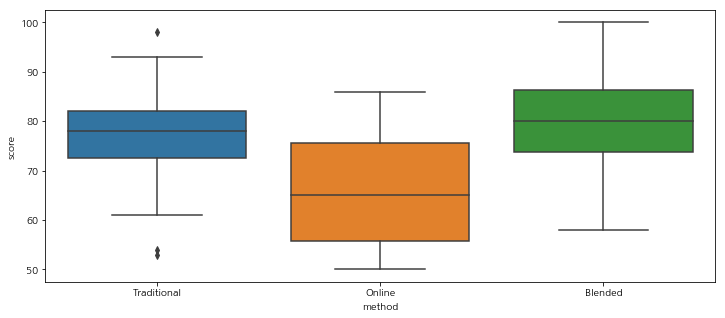

In [28]:
#시각화
plt.figure(figsize = (12, 5))
sns.boxplot(data=mt, x='method', y='score')
plt.show()

### 4. 통계분석

#### [문제 4] 회귀분석: 학업 성취도 예측

#### 데이터셋은 학생 500명의 학업 관련 변수를 포함하며, 국어 성적을 예측하는 회귀분석을 수행합니다.

- 변수:
- ID: 학생 식별자
- StudyTime: 주간 공부시간 (0: 10시간 이하, 1: 1115시간, 2: 1620시간, 3: 21~25시간, 4: 26시간 이상)
- Tutoring: 과외 여부 (Yes/No)
- OnlineCourse: 온라인 강의 수강 여부 (Yes/No)
- Absences: 결석 일수 (평균 4, Q3: 8, 최대 25)
- Failures: 낙제 횟수 (0~3)
- Score: 국어 성적 (0~20점)
#### 데이터 특이사항:
- 결측값: 약 5% (Absences, Failures 중심).
- 범주형 변수(Tutoring, OnlineCourse)는 더미 변수로 변환 필요.
- Python(sklearn, statsmodels) 또는 R(lm, randomForest) 사용 권장.

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./Academic_Performance.csv')
df.head()

,id,StudyTime,Tutoring,OnlineCourse,Absences,Failures,Score
0,1,3,Yes,Yes,8.0,0.0,12
1,2,1,Yes,Yes,4.0,2.0,11
2,3,1,Yes,No,7.0,1.0,14
3,4,2,No,No,7.0,1.0,14
4,5,0,No,Yes,5.0,1.0,11


In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            500 non-null    int64  
 1   StudyTime     500 non-null    int64  
 2   Tutoring      500 non-null    object 
 3   OnlineCourse  500 non-null    object 
 4   Absences      475 non-null    float64
 5   Failures      475 non-null    float64
 6   Score         500 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


In [301]:
# 결측치를 삭제한다면 레코드 수
df.dropna(inplace=True)

전체 데이터 대비 2개의 컬럼에서 25개의 결측치가 확인되었다. 시간이 충분하다면, 각 변수들 간의 관계를 이용하여 보간하면 될 것 같은데  
전체의 5% 정도로 큰 비중을 차지하지 않으며, 대푯값으로 치환하면 데이터의 왜곡을 불러올 수 있으므로 삭제한다.

#### 가정 검토:
선형회귀 가정(선형성, 정규성, 등분산, 독립성) 검토.
잔차 플롯 및 Q-Q 플롯 시각화.

In [306]:
#모델 적합 후 잔차검정 시행
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#귀무가설: 모든 회귀계수는 0이다.  
#대립가설: 적어도 하나의 회귀계수는 0이 아니다. 

x = df.drop(['id', 'Score'], axis=1)
y = df['Score']

c_cols = c_cols = ['StudyTime', 'Tutoring', 'OnlineCourse']

x = pd.get_dummies(x, columns=c_cols, drop_first=True)


train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)

#스케일링
sc = StandardScaler()

x = sc.fit_transform(train_x)
x = sm.add_constant(x)

model = sm.OLS(train_y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.309
Date:                Tue, 30 Sep 2025   Prob (F-statistic):              0.238
Time:                        10:10:05   Log-Likelihood:                -892.19
No. Observations:                 356   AIC:                             1802.
Df Residuals:                     347   BIC:                             1837.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.5449      0.159     91.349      0.0

선형회귀모델은 잔차의 가정을 만족해야만 모델의 성능이 보장된다. (모델의 F통계량은 0.238으로 통계적으로 유의하지 않음)  
선형성, 독립성, 등분산성, 정규성 검정을 실시한다.  

잔차 정규성 검정결과: 0.065 만족
잔차 등분산성 검정결과: 0.442 만족
더빈왓슨 자기상관 검정결과: 1.901287301373147


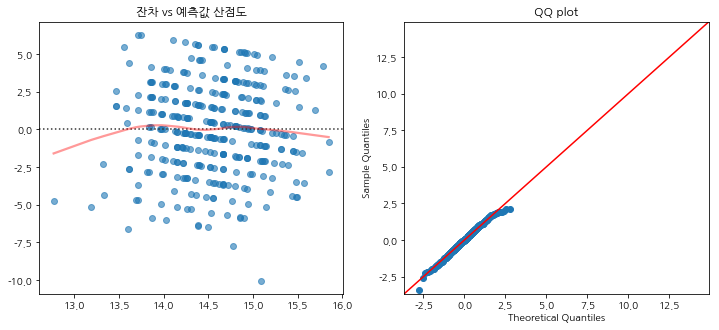

In [310]:
from statsmodels.stats.diagnostic import het_breuschpagan

# 잔차검정
fitted = model.fittedvalues
resid = model.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#1) 잔차 vs 예측값 산점도(등분산성/선형성 확인)
sns.residplot(x=fitted, y=resid, lowess=True, scatter_kws={'alpha': 0.6}, line_kws={'alpha':0.4, 'color':'r'}, ax=ax[0])
ax[0].set_title('잔차 vs 예측값 산점도')

#2) QQ 플롯
sm.qqplot(resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('QQ plot')

#3) shapiro(정규성)
stat, p = shapiro(resid)

print(f"잔차 정규성 검정결과: {p:.3f}", "만족" if p >=0.05 else "불만족")

# 4) 브레슈-파간(등분산성)
stat, p, _, _ = het_breuschpagan(resid, model.model.exog)

print(f"잔차 등분산성 검정결과: {p:.3f}", "만족" if p >=0.05 else "불만족")

# 5) 더빈왓슨
dw = durbin_watson(resid)
print(f"더빈왓슨 자기상관 검정결과: {dw}")


잔차 검정결과 등분산성/독립성/정규성/선형성 가정을 모두 만족한다.  

- 등분산성: 잔차-예측값 산점도 상 0기준으로 고르게 분포, 브레슈파간 검정 결과 귀무가설 기각 불가
- 독립성: 더빈왓슨 검정결과 2에 가까움
- 정규성: 샤피로 검정 결과 귀무가설 기각 불가
- 선형성: 잔차-예측값 산점도 상 특이패턴 없으며, 잔차 무작위 배치

따라서 선형회귀 사용이 적합하다. (단 통계적으로 유의하지 않으므로 데이터 재검토 필요)

- 기본가정 불만족 시: 예측 성능 저하, 계수 해석 오류(회귀계수가 실제변수 간 관계 왜곡), 통계저거 추론 문제

#### 회귀분석:
선형회귀분석 수행(종속변수: Score, 독립변수: StudyTime, Tutoring, OnlineCourse, Absences, Failures).
기계학습 모델(예: 랜덤포레스트)과 비교.

In [313]:
# 랜덤포레스트 모델적합 후 성능 비교
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(random_state=42)

rf.fit(train_x, train_y)


m_list = [('선형회귀', model), ('랜덤포레스트 회귀', rf)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'dada', 'r2', 'rmse'])

for name, m in m_list:
    for dm, x, y in d_list:
        if name == "선형회귀":
            x2 = sc.transform(x)
            x2 = sm.add_constant(x2)
            pred = m.predict(x2)
        else:
            pred = m.predict(x)
        rmse = np.sqrt(mean_squared_error(y, pred))
        r2 = r2_score(y, pred)
        rs.loc[len(rs)] = [name, dm, r2, rmse]
display(rs)

,model,dada,r2,rmse
0,선형회귀,train,0.029284,2.966007
1,선형회귀,test,-0.036000,2.701539
2,랜덤포레스트 회귀,train,0.549281,2.021060
3,랜덤포레스트 회귀,test,-0.474444,3.222889


In [316]:
2.701539/(test_y.max()-test_y.min())

0.22512825

두 모델을 비교할 때 선형회귀 모델의 성능이 전반적으로 뛰어난 것을 확인할 수 있다.

#### 다중공선성:
VIF(Variance Inflation Factor) 계산 및 다중공선성 평가.

In [314]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = model.model.exog_names
vif['vif'] = [variance_inflation_factor(model.model.exog, i) for i in range(len(model.model.exog_names))]

display(vif[1:])

,name,vif
1,x1,1.036553
2,x2,1.019823
3,x3,1.653966
4,x4,1.717767
5,x5,1.397598
6,x6,1.303099
7,x7,1.021990
8,x8,1.024629


회귀모형의 입력값을 활용한 다중공선성 진단결과이다.  
vif 값이 10이상인 경우를 다중공선성으로 일반적으로 진단하는 것을 적용 시 모든 feature의 계수가 1에 가까운 값으로  
독립적이며 다중공선성이 없다. 

#### 변수 중요도:
회귀계수의 p-value를 통해 통계적 유의성 확인.
랜덤포레스트의 feature importance 분석.

In [317]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.309
Date:                Tue, 30 Sep 2025   Prob (F-statistic):              0.238
Time:                        10:34:38   Log-Likelihood:                -892.19
No. Observations:                 356   AIC:                             1802.
Df Residuals:                     347   BIC:                             1837.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.5449      0.159     91.349      0.0

해당 회귀모델의 F통계량 pvalue가 0.238이므로 회귀계수에 대한 통계적 유의성을 만족하지 않는다. (귀무가설 기각 불가)  
따라서 모든 회귀계수가 0이 아니라는 것은 통계적으로 유의하지 않는다.  

만약 모델의 F통계량이 대립가설을 채택한다면, 각 변수의 t통계량 p-value가 유의수준 5% 하에서 유의한지 검정할 수 있다.  
그리고 유의한 변수의 계수에 대한 중요도를 오즈비검정을 통해 알 수 있다.

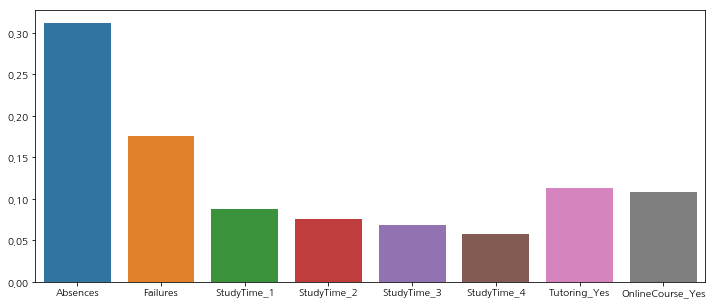

In [318]:
name = train_x.columns
imp = rf.feature_importances_

plt.figure(figsize=(12, 5))
sns.barplot(x=name, y=imp)
plt.show()

다음은 랜덤포레스트 학습결과 후 각 변수별 학습 중요도이다.  
Absences > failure > Tutoring > Online  순으로 학습에 기여한 것을 알 수 있으며, 학습시간 기여율은 낮은 편이다.

#### 모델 평가:
R²: 모델이 성적의 변동을 얼마나 설명하는지 해석.
RMSE: 예측 오차 평가.

선형회귀 모델의 train set 기준으로는 r2 score가 0.029284로 성적의 변동의 약 2.92%를 설명하는 아주 낮은 설명력을 가지고 있으며, 

test set기준 선형회귀의 rmse는 2.701539로 test set 대비 약 22.5% 의 표준오차,   
r2 score가 -0.036000 음수로 단순하게 평균을 예측하는 것보다 성능이 떨어지는 것을 확인할 수 있다.   
설명변수의 재검토를 통해 유의미한 파생변수를 생성한다던지 하는 과정이 필요할 것이다. 